In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# Load 2010 baseball season data
df2010 = pd.read_csv("baseball10.csv")

# Load 2021 baseball season data for comparison
df2021 = pd.read_csv("baseball21.csv")

print("2010 data shape:", df2010.shape)
print("2021 data shape:", df2021.shape)
print("\n2010 data columns:", df2010.columns.tolist())
print("\nFirst few rows of 2010 data:")
print(df2010.head())

2010 data shape: (2430, 7)
2021 data shape: (2429, 7)

2010 data columns: ['date', 'visiting', 'home', 'visScore', 'homeScore', 'visHR', 'homeHR']

First few rows of 2010 data:
       date visiting home  visScore  homeScore  visHR  homeHR
0  20100404      NYA  BOS         7          9      2       1
1  20100405      MIN  ANA         3          6      1       3
2  20100405      CLE  CHA         0          6      0       2
3  20100405      DET  KCA         8          4      0       1
4  20100405      SEA  OAK         5          3      1       0


In [4]:
# Stage 2: Curation of Content
# Aggregate data to get average runs per stadium

# Process 2010 data
avgDF_2010 = (df2010
    .assign(totalRuns = lambda df: df.homeScore + df.visScore)
    .assign(totalHR = lambda df: df.homeHR + df.visHR)
    .drop(columns = ['date', 'visiting'])
    .groupby(['home'], as_index=False)
    .mean()
)

# Process 2021 data
avgDF_2021 = (df2021
    .assign(totalRuns = lambda df: df.homeScore + df.visScore)
    .assign(totalHR = lambda df: df.homeHR + df.visHR)
    .drop(columns = ['date', 'visiting'])
    .groupby(['home'], as_index=False)
    .mean()
)

print("2010 Stadium Averages (Top 5):")
print(avgDF_2010.head())
print("\n2021 Stadium Averages (Top 5):")
print(avgDF_2021.head())

2010 Stadium Averages (Top 5):
  home  visScore  homeScore     visHR    homeHR  totalRuns   totalHR
0  ANA  3.975309   3.938272  0.839506  0.851852   7.913580  1.691358
1  ARI  5.049383   4.740741  1.271605  1.209877   9.790123  2.481481
2  ATL  3.641975   4.827160  0.740741  0.913580   8.469136  1.654321
3  BAL  5.111111   3.975309  1.308642  0.888889   9.086420  2.197531
4  BOS  4.851852   5.172840  0.876543  1.209877  10.024691  2.086420

2021 Stadium Averages (Top 5):
  home  visScore  homeScore     visHR    homeHR  totalRuns   totalHR
0  ANA  4.925926   4.703704  1.283951  1.296296   9.629630  2.580247
1  ARI  5.456790   4.555556  1.246914  0.851852  10.012346  2.098765
2  ATL  4.400000   5.050000  1.200000  1.450000   9.450000  2.650000
3  BAL  6.259259   4.469136  1.913580  1.506173  10.728395  3.419753
4  BOS  4.962963   5.802469  1.111111  1.333333  10.765432  2.444444


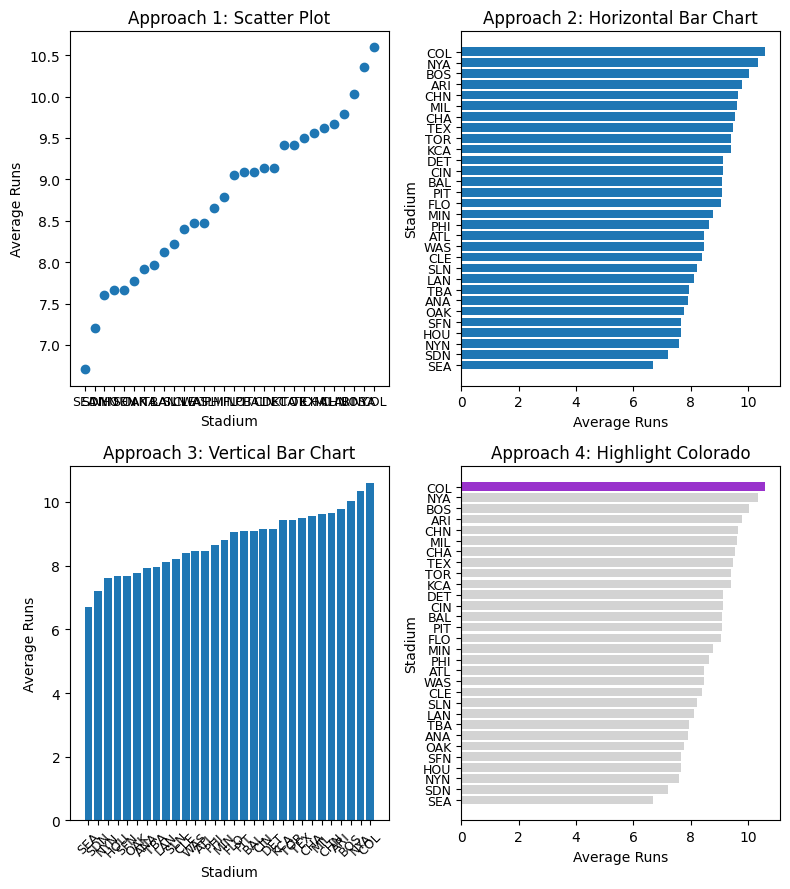

In [5]:
# Stage 3: Structuring of Visual Mappings
# Explore different geometries and aesthetics

# Sort data for better visualization
avgDF_2010_sorted = avgDF_2010.sort_values('totalRuns', ascending=True)

# Create figure with subplots to compare approaches
fig, axes = plt.subplots(2, 2, figsize=(8, 9))

# Approach 1: Scatter plot (not ideal for categorical data)
axes[0,0].scatter(avgDF_2010_sorted.home, avgDF_2010_sorted.totalRuns)
axes[0,0].set_title("Approach 1: Scatter Plot")
axes[0,0].set_xlabel("Stadium")
axes[0,0].set_ylabel("Average Runs")
axes[0,0].tick_params(axis='x', labelsize=9)

# Approach 2: Horizontal bar chart (better for categorical data)
axes[0,1].barh(avgDF_2010_sorted.home, avgDF_2010_sorted.totalRuns)
axes[0,1].set_title("Approach 2: Horizontal Bar Chart")
axes[0,1].set_xlabel("Average Runs")
axes[0,1].set_ylabel("Stadium")
axes[0,1].tick_params(axis='y', labelsize=9)

# Approach 3: Vertical bar chart
axes[1,0].bar(avgDF_2010_sorted.home, avgDF_2010_sorted.totalRuns)
axes[1,0].set_title("Approach 3: Vertical Bar Chart")
axes[1,0].set_xlabel("Stadium")
axes[1,0].set_ylabel("Average Runs")
axes[1,0].tick_params(axis='x', rotation=45, labelsize=9)

# Approach 4: Highlight Colorado
colorado_colors = ["darkorchid" if stadium == "COL" else "lightgrey" 
                   for stadium in avgDF_2010_sorted.home]
axes[1,1].barh(avgDF_2010_sorted.home, avgDF_2010_sorted.totalRuns, color=colorado_colors)
axes[1,1].set_title("Approach 4: Highlight Colorado")
axes[1,1].set_xlabel("Average Runs")
axes[1,1].set_ylabel("Stadium")
axes[1,1].tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.show()

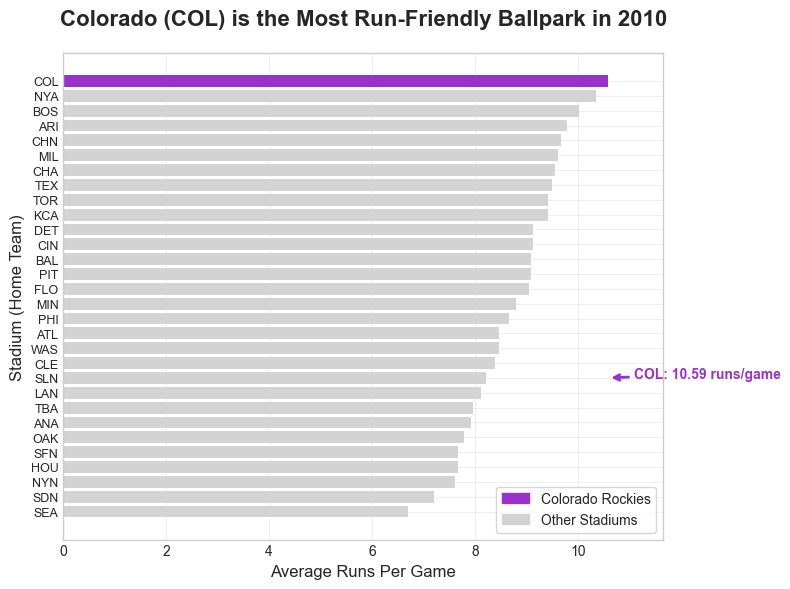


Summary Statistics for 2010:
Colorado (COL) average runs per game: 10.59
League average runs per game: 8.77
Colorado is 20.8% above league average


In [6]:
# Stage 4: Formatting for Your Audience
# Create a professional, publication-ready visualization

# Set style for professional appearance
plt.style.use("seaborn-v0_8-whitegrid")

# Create the main visualization
fig, ax = plt.subplots(figsize=(8, 6))

# Create color array for highlighting Colorado
colorado_colors = ["darkorchid" if stadium == "COL" else "lightgrey" 
                   for stadium in avgDF_2010_sorted.home]

# Create horizontal bar chart
bars = ax.barh(avgDF_2010_sorted.home, avgDF_2010_sorted.totalRuns, color=colorado_colors)

# Add title and labels
ax.set_title("Colorado (COL) is the Most Run-Friendly Ballpark in 2010", 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Average Runs Per Game", fontsize=12)
ax.set_ylabel("Stadium (Home Team)", fontsize=12)

# Add legend
colorado_bar = plt.Rectangle((0,0),1,1, color="darkorchid", label="Colorado Rockies")
other_bar = plt.Rectangle((0,0),1,1, color="lightgrey", label="Other Stadiums")
ax.legend(handles=[colorado_bar, other_bar], loc='lower right', frameon=True)

# Add annotation for Colorado
colorado_index = avgDF_2010_sorted[avgDF_2010_sorted.home == "COL"].index[0]
colorado_runs = avgDF_2010_sorted[avgDF_2010_sorted.home == "COL"]["totalRuns"].iloc[0]
ax.annotate(f"COL: {colorado_runs:.2f} runs/game", 
            xy=(colorado_runs, colorado_index), 
            xytext=(colorado_runs + 0.5, colorado_index),
            arrowprops=dict(arrowstyle='->', color='darkorchid', lw=2),
            fontsize=10, fontweight='bold', color='darkorchid')

# Set x-axis to start from 0 for better comparison
ax.set_xlim(0, max(avgDF_2010_sorted.totalRuns) * 1.1)

# Smaller font for stadium (y-axis) tick labels
ax.tick_params(axis='y', labelsize=9)

# Add grid for easier reading
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nSummary Statistics for 2010:")
print(f"Colorado (COL) average runs per game: {colorado_runs:.2f}")
print(f"League average runs per game: {avgDF_2010_sorted.totalRuns.mean():.2f}")
print(f"Colorado is {((colorado_runs / avgDF_2010_sorted.totalRuns.mean()) - 1) * 100:.1f}% above league average")

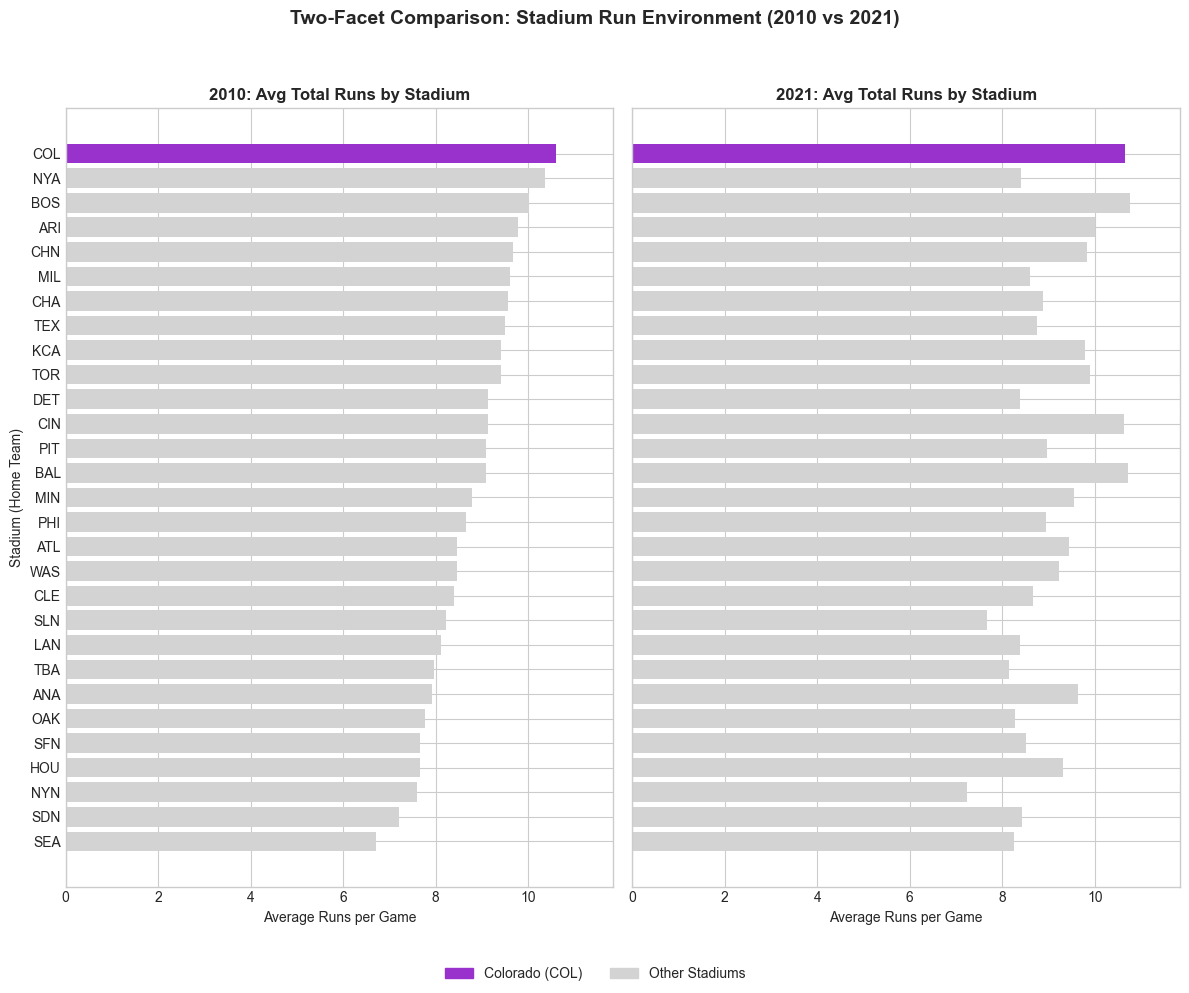

In [10]:
# Advanced Object-Oriented Techniques
# Create a comprehensive comparison visualization

# Prepare data for comparison
comparison_data = pd.merge(
    avgDF_2010[['home', 'totalRuns']].rename(columns={'totalRuns': 'runs_2010'}),
    avgDF_2021[['home', 'totalRuns']].rename(columns={'totalRuns': 'runs_2021'}),
    on='home', how='inner'
)

# Sort stadiums for clean ranking (use 2010 for consistent order)
plot_df = comparison_data.sort_values("runs_2010", ascending=True).reset_index(drop=True)

# Create color list to highlight Colorado
colors = ["darkorchid" if team == "COL" else "lightgrey" 
          for team in plot_df["home"]]

# Create two-panel object-oriented figure
fig, axes = plt.subplots(1, 2, figsize=(12, 10), sharey=True)

# ---- Left Panel: 2010 ----
axes[0].barh(plot_df["home"], plot_df["runs_2010"], color=colors)
axes[0].set_title("2010: Avg Total Runs by Stadium", fontweight="bold")
axes[0].set_xlabel("Average Runs per Game")
axes[0].set_ylabel("Stadium (Home Team)")

# ---- Right Panel: 2021 ----
axes[1].barh(plot_df["home"], plot_df["runs_2021"], color=colors)
axes[1].set_title("2021: Avg Total Runs by Stadium", fontweight="bold")
axes[1].set_xlabel("Average Runs per Game")

# Ensure same x-axis scale for fair comparison
max_runs = max(plot_df["runs_2010"].max(), plot_df["runs_2021"].max())
axes[0].set_xlim(0, max_runs * 1.1)
axes[1].set_xlim(0, max_runs * 1.1)

# Add legend
col_patch = plt.Rectangle((0,0),1,1, color="darkorchid", label="Colorado (COL)")
oth_patch = plt.Rectangle((0,0),1,1, color="lightgrey", label="Other Stadiums")
fig.legend(handles=[col_patch, oth_patch], loc="lower center", ncol=2)

# Add overall title
fig.suptitle("Two-Facet Comparison: Stadium Run Environment (2010 vs 2021)", 
             fontsize=14, fontweight="bold")

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()
